0.0003136021697745725
0.0003033797377874621
0.0003102812312371966
0.0003092845661648639
0.0003166845033652173
0.00031283645883034783
0.00030180655146222463
0.0002974985577577362
0.0003028544845072737
0.00030174692486016706
0.00029355573117700705
0.0003089589799779521
0.000307170749053515
0.0002947805675306857
0.0003042829947338226
0.00030214602245392884
0.0002942962176562584
0.00028739560007743606
0.0002875772087053146
0.00029896472329365433
0.0002881758479521803
0.00029546261721005685
0.0002922710675980317
0.00029160818855552623
0.000288643711800957
0.00027445324934030423
0.0002827156586649828
0.0002727663274109489
0.0002829446991257824
0.00027302222408713024
0.00028038294499218853
0.00026701245310178966
0.0002634536718836013
0.0002740864056010762
0.00026605126815062454
0.00026028206798784384
0.0002673746018115668
0.00025575664861056483
0.00025277983929950686
0.0002609315863131829
0.0002482710580600243
0.00025526930209384476
0.0002484665773080655
0.0002466628470621143
0.00024824206319

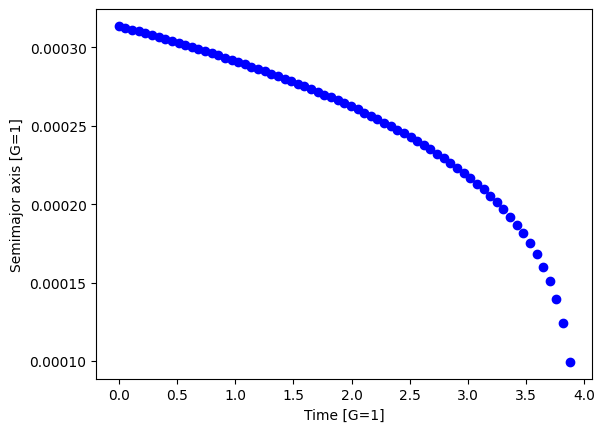

In [5]:
import rebound
import reboundx
import numpy as np
import matplotlib.pyplot as plt

sim = rebound.Simulation()
#sim.units = ('AU', 'yr', 'Msun')
sim.G=1
sim.integrator='ias15'
sim.dt=0.01

sim.add(m=1.00000001E-01,x=   -2.86636483E+00,y= -3.51352660E+00,z=  1.31048588E+00,\
        vx=-8.29922019E+00,vy= -2.77660036E+00,vz= -1.16069792E-01)
sim.add(m=5.99999987E-02,x=   -2.86626798E+00,y= -3.51381408E+00,z=  1.31048970E+00,\
        vx=1.38346340E+01,vy=  4.61131049E+00,vz=  1.91195042E-01)
sim.move_to_com()
star = sim.particles[1]

rebx = reboundx.Extras(sim)

sse = rebx.load_force('post_newtonian')
rebx.add_force(sse)
sse.params['pn_2PN']=0
sse.params['pn_25PN']=1
sse.params['c']=457.14

print (star.a)

timearray=[]
aarray = []

#plt.scatter(0.,star.a,c='b')
#timearray.append(0.)
#aarray.append(star.a)

for time in np.linspace(0,4.5,80):
    sim.integrate(time)
    print (np.sqrt((sim.particles[0].x-sim.particles[1].x)**2.+(sim.particles[0].y-sim.particles[1].y)**2.+\
          (sim.particles[0].z-sim.particles[1].z)**2.))
    timearray.append(sim.t)
    aarray.append(star.a)
    plt.scatter(time,star.a,c='b')

plt.xlabel('Time [G=1]')
plt.ylabel('Semimajor axis [G=1]')

plt.show()


In [28]:
import csv
with open("fazeel.csv", "w", newline="") as f:
    writer = csv.writer(f)
    # Write header
    writer.writerow(["Time", "semimajor"])
    # Write rows
    for i in range(len(timearray)):
        writer.writerow([timearray[i], aarray[i]])

In [2]:
aarray

[0.0003136021697745725,
 0.00031125309357400336,
 0.0003088563407077376,
 0.000306395778579573,
 0.00030388059689182776,
 0.00030129903406472987,
 0.0002986512196743129,
 0.00029593086150713936,
 0.00029313796572421404,
 0.0002902556606863719,
 0.0002872894454575238,
 0.00028422949453639593,
 0.00028106744087412825,
 0.0002777980917412884,
 0.0002744030804934979,
 0.00027088304624980214,
 0.00026722080819650015,
 0.00026340029471748767,
 0.00025940630086298167,
 0.0002552207812394938,
 0.00025081517991026425,
 0.0002461703298100334,
 0.0002412449105402384,
 0.00023599939197765032,
 0.00023038007821439042,
 0.00022431765545541388,
 0.00021772409540077797,
 0.0002104687530420445,
 0.0002023721554391839,
 0.00019317511961112736,
 0.00018243669977880862,
 0.000169376626869488,
 0.00015231639725429957,
 0.00012618262819286537,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan]